In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeUniform
import pandas as pd
import scienceplots
plt.style.use(['science','bright'])
# plt.style.use(['science', 'std-colors'])
plt.rcParams.update({'figure.dpi': '150'})
mcolors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.style.use(['no-latex']) 

In [39]:
# === USER FLAG TO CHOOSE DEVICE ===
use_gpu = True # Set to False to force CPU

# === Automatically choose device string ===
device = '/GPU:0' if use_gpu and tf.config.list_physical_devices('GPU') else '/CPU:0'
print(f"Running on device: {device}")

Running on device: /GPU:0


In [40]:

# Noise token if needed (currently unused)
noise_token = 0


x =np.linspace(0,1,201)

# Grid and time-step setup
nx = x.shape[0]
L = np.max(x) - np.min(x)
dx = L / nx
c = 1.0
CFL = 0.95
dt = CFL * dx / c
convection_time = L / c
time = 1 * convection_time
nt = int(time / dt)
print(f"dx = {dx:.5f}, nx = {nx}, dt = {dt:.5f}, nt = {nt}, total time = {time:.3f}")


dx = 0.00498, nx = 201, dt = 0.00473, nt = 211, total time = 1.000


In [41]:

# Initial condition


def u_initial_sine(X):
    pi = tf.acos(-1.0)
    F = tf.sin(2.0 * pi * X)
    scale = tf.reduce_max(tf.abs(F))
    return F / scale

Nx = 100
N = Nx - 2
M = 3 * N // 2
dx = 1.0 / (N + 1)
x_internal = np.arange(1, N+1) * dx
k = np.arange(1, N+1)
pi_k = np.pi * k
sin_matrix = np.sin( np.outer(pi_k, x_internal) )
cos_matrix = np.cos( np.outer(pi_k, x_internal) )
# For dealiasing
x_fine = np.arange(1, M+1) * 1.0 / (M +1)
k_ext = np.arange(1, M+1)
pi_k_ext = np.pi * k_ext
sin_matrix_fine = np.sin( np.outer(pi_k_ext, x_fine) )
cos_matrix_fine = np.cos( np.outer(pi_k_ext, x_fine) )
nu = 0.01 / np.pi
T = 0.3
# IC
u = np.sin(2 * np.pi * x_internal)
a = (2 / (N + 1)) * np.dot(sin_matrix, u)
# dt
u_max = np.max(np.abs(u))
dt_diff = 2.5 * dx**2 / nu
dt_conv = 0.6 * dx / u_max if u_max > 0 else dt_diff
dt = min(dt_diff, dt_conv)
nt = int(T / dt) + 1
dt = T / nt
for n in range(nt):
    # RK4
    # k1
    a_temp = a
    a_ext = np.concatenate( (a_temp, np.zeros(M - N) ) )
    u1 = np.dot( sin_matrix_fine.T, a_ext )
    u_x1 = np.dot( cos_matrix_fine.T, pi_k_ext * a_ext )
    nonlinear1 = u1 * u_x1
    b1 = (2 / (M + 1)) * np.dot(sin_matrix_fine[0:N, :], nonlinear1)
    da1 = -b1 + nu * (-pi_k**2) * a_temp
    # k2
    a_temp = a + 0.5 * dt * da1
    a_ext = np.concatenate( (a_temp, np.zeros(M - N) ) )
    u2 = np.dot( sin_matrix_fine.T, a_ext )
    u_x2 = np.dot( cos_matrix_fine.T, pi_k_ext * a_ext )
    nonlinear2 = u2 * u_x2
    b2 = (2 / (M + 1)) * np.dot(sin_matrix_fine[0:N, :], nonlinear2)
    da2 = -b2 + nu * (-pi_k**2) * a_temp
    # k3
    a_temp = a + 0.5 * dt * da2
    a_ext = np.concatenate( (a_temp, np.zeros(M - N) ) )
    u3 = np.dot( sin_matrix_fine.T, a_ext )
    u_x3 = np.dot( cos_matrix_fine.T, pi_k_ext * a_ext )
    nonlinear3 = u3 * u_x3
    b3 = (2 / (M + 1)) * np.dot(sin_matrix_fine[0:N, :], nonlinear3)
    da3 = -b3 + nu * (-pi_k**2) * a_temp
    # k4
    a_temp = a + dt * da3
    a_ext = np.concatenate( (a_temp, np.zeros(M - N) ) )
    u4 = np.dot( sin_matrix_fine.T, a_ext )
    u_x4 = np.dot( cos_matrix_fine.T, pi_k_ext * a_ext )
    nonlinear4 = u4 * u_x4
    b4 = (2 / (M + 1)) * np.dot(sin_matrix_fine[0:N, :], nonlinear4)
    da4 = -b4 + nu * (-pi_k**2) * a_temp
    # Update
    a += (dt / 6.0) * (da1 + 2*da2 + 2*da3 + da4)
# Final u_internal
u_internal = np.dot(sin_matrix.T, a)  # use original for final
# Full u
u_FD_sine = np.zeros(Nx)
u_FD_sine[1:-1] = u_internal
x = np.linspace(0,1,Nx)




In [42]:


class PINN(tf.keras.Model):
    def __init__(self, input_dim=2, output_dim=1, use_bias=True):
        super().__init__()
        self.net = Sequential([
            Dense(100, input_shape=(input_dim,), activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(100, activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(100, activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(100, activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(100, activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(100, activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(100, activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(100, activation='tanh', use_bias=use_bias, kernel_initializer=HeUniform()),
            Dense(output_dim, use_bias=use_bias, kernel_initializer=HeUniform())
        ])

    def call(self, X):
        return self.net(X)

# Initialize model
model = PINN()

# --- Step 1: Call the model once with dummy input to create weights ---
dummy_input = tf.zeros((1, 2), dtype=tf.float32)  # shape=(batch_size, input_dim)
_ = model(dummy_input)

# --- Step 2: Load saved weights ---
weights_path = "./checkpoints/pinn_burgers_weights_sine.h5"
model.load_weights(weights_path)
print(f"Loaded weights from {weights_path}")


Loaded weights from ./checkpoints/pinn_burgers_weights_sine.h5


In [43]:
def save_hidden_weights_biases_txt(model, file_1=None, file_2=None):
    """
    Save only hidden layer weights and biases of a Keras PINN model
    into a plain text file.
    """
    # with open(filename, "w") as f:
        # Hidden layers are 2 through 8 (index 1 to 7 in model.net.layers)
    for i, layer in enumerate(model.net.layers[:], start=0):
            filename_1 = f"{file_1.split('.txt')[0]}_layer{i}.txt"
            filename_2 = f"{file_2.split('.txt')[0]}_layer{i}.txt"

            with open(filename_1, "w") as f:

                if isinstance(layer, tf.keras.layers.Dense):
                    weights = layer.get_weights()
                    
                    if len(weights) == 2:
                        W, b = weights
                    elif len(weights) == 1:  # No bias case
                        W, b = weights[0], None
                    else:
                        continue  # Skip layers with no weights

                    # Save weights
                    f.write(f"#Layer {i} Weights:\n")
                    np.savetxt(f, W, fmt="%.18f", delimiter=" ")

            with open(filename_2, "w") as f:

                    # Save biases
                    if b is not None:
                        f.write(f"#Layer {i} Biases:\n")
                        np.savetxt(f, b.reshape(1, -1), fmt="%.18f", delimiter=" ")

            print(f"Hidden layer weights and biases saved to {filename_1}, {filename_2}")


save_hidden_weights_biases_txt(model, file_1="./weights_sine/weights_burgers.txt", file_2="./weights_sine/biases_burgers.txt")


Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer0.txt, ./weights_sine/biases_burgers_layer0.txt
Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer1.txt, ./weights_sine/biases_burgers_layer1.txt
Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer2.txt, ./weights_sine/biases_burgers_layer2.txt
Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer3.txt, ./weights_sine/biases_burgers_layer3.txt
Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer4.txt, ./weights_sine/biases_burgers_layer4.txt
Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer5.txt, ./weights_sine/biases_burgers_layer5.txt
Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer6.txt, ./weights_sine/biases_burgers_layer6.txt
Hidden layer weights and biases saved to ./weights_sine/weights_burgers_layer7.txt, ./weights_sine/biases_burgers_layer7.txt


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity


def fit_kde_cv(data, bandwidths=np.logspace(-3, -1, 20), cv=3):
    data = data[:, np.newaxis]
    
    grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                        {'bandwidth': bandwidths},
                        cv=cv)
    grid.fit(data)

    best_kde = grid.best_estimator_
    best_bw = grid.best_params_['bandwidth']
    
    # Get CV results
    results = pd.DataFrame(grid.cv_results_)
    results = results[['param_bandwidth', 'mean_test_score']]
    results.rename(columns={
        'param_bandwidth': 'Bandwidth',
        'mean_test_score': 'Mean CV Log-Likelihood'
    }, inplace=True)
    results['Mean CV Log-Likelihood'] = results['Mean CV Log-Likelihood'].round(4)
    
    # Highlight best
    best_row = results.loc[results['Bandwidth'] == best_bw]
    print("\nCross-Validation Results:")
    print(results.to_string(index=False))
    print(f"\n Best Bandwidth: {best_bw:.4f} (Highest Log-Likelihood: {best_row['Mean CV Log-Likelihood'].values[0]:.4f})")


    return best_kde, best_bw

# --- Extract weights & biases from your model ---
W1 = model.net.layers[1].weights[0].numpy().flatten()
b1 = model.net.layers[1].weights[1].numpy().flatten()
W4 = model.net.layers[4].weights[0].numpy().flatten()
b4 = model.net.layers[4].weights[1].numpy().flatten()
W7 = model.net.layers[7].weights[0].numpy().flatten()
b7 = model.net.layers[7].weights[1].numpy().flatten()

# Fit KDEs with cross-validated bandwidths
kde_w1, bw_w1 = fit_kde_cv(W1)
kde_w4, bw_w4 = fit_kde_cv(W4)
kde_w7, bw_w7 = fit_kde_cv(W7)


# Fit KDEs with cross-validated bandwidths
kde_b1, bw_b1,  = fit_kde_cv(b1)
kde_b4, bw_b4,  = fit_kde_cv(b4)
kde_b7, bw_b7,  = fit_kde_cv(b7)


Cross-Validation Results:
 Bandwidth  Mean CV Log-Likelihood
  0.001000               2381.9947
  0.001274               2507.7842
  0.001624               2586.7133
  0.002069               2636.4611
  0.002637               2667.8022
  0.003360               2687.6888
  0.004281               2700.5171
  0.005456               2708.8330
  0.006952               2714.1972
  0.008859               2717.6832
  0.011288               2719.7240
  0.014384               2720.1186
  0.018330               2718.2637
  0.023357               2712.9779
  0.029764               2701.8970
  0.037927               2680.7779
  0.048329               2642.8165
  0.061585               2578.6136
  0.078476               2477.2580
  0.100000               2325.9454

 Best Bandwidth: 0.0144 (Highest Log-Likelihood: 2720.1186)

Cross-Validation Results:
 Bandwidth  Mean CV Log-Likelihood
  0.001000              -9269.7537
  0.001274              -4725.9900
  0.001624              -1926.7457
  0.002069

In [ ]:
# Viscous Burgers

from scipy.stats import kurtosis

def print_excess_kurtosis(data, label="Data"):
    """
    Compute and print excess kurtosis for a dataset.
    Gaussian baseline = 0.
    """
    ek = kurtosis(data, fisher=False)  # fisher=True implies excess kurtosis
    print(f"Kurtosis for {label}: {ek:.4f}")
    return ek

print_excess_kurtosis(W1, "Layer 1 Weights")
print_excess_kurtosis(b1, "Layer 1 Biases")
print_excess_kurtosis(W4, "Layer 4 Weights")
print_excess_kurtosis(b4, "Layer 4 Biases")
print_excess_kurtosis(W7, "Layer 7 Weights")
print_excess_kurtosis(b7, "Layer 7 Biases")

Kurtosis for Layer 1 Weights: 2.1457
Kurtosis for Layer 1 Biases: 1.9347
Kurtosis for Layer 4 Weights: 2.9441
Kurtosis for Layer 4 Biases: 5.7961
Kurtosis for Layer 7 Weights: 1.9694
Kurtosis for Layer 7 Biases: 2.3865


2.3865324528142744

Integral: 1.1141853757113152


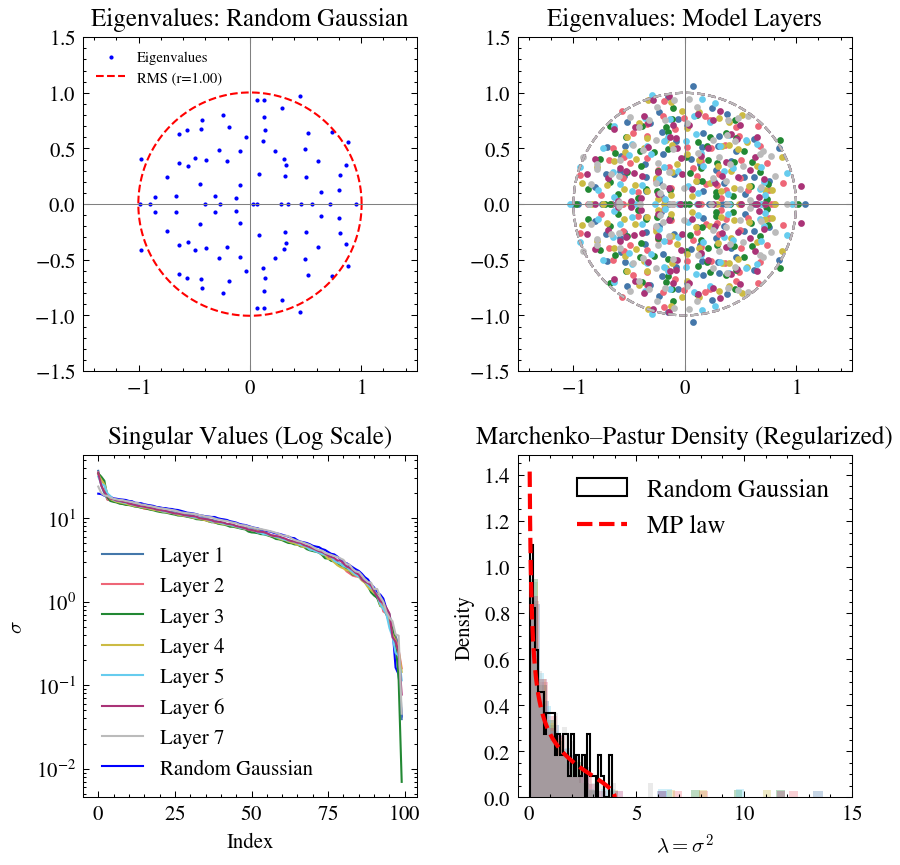

In [28]:
import matplotlib.gridspec as gridspec

def get_eigen_spectrum(W, label):
    n = W.shape[0]
    assert n == W.shape[1], f"{label} is not square!"
    rms = np.sqrt(np.mean(W**2))
    W_scaled = W / np.sqrt(n)
    eigvals = np.linalg.eigvals(W_scaled)
    return eigvals, rms

def get_singular_spectrum(W):
    return np.linalg.svd(W, compute_uv=False)

def mp_density(lam, q):
    lam_plus = (1 + np.sqrt(q))**2
    lam_minus = (1 - np.sqrt(q))**2
    rho = np.zeros_like(lam)
    mask = (lam >= lam_minus) & (lam <= lam_plus)
    rho[mask] = np.sqrt((lam_plus - lam[mask]) *
                        (lam[mask] - lam_minus)) / (2 * np.pi * q * lam[mask])
    return rho


lam_test = np.linspace(1e-6, 4.0, 5000)
rho = mp_density(lam_test, q=1.0)
print("Integral:", np.trapz(rho, lam_test))


# ============================
# Figure layout (2x2)
# ============================
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
ax0, ax1, ax2, ax3 = axes.flatten()

theta = np.linspace(0, 2*np.pi, 300)
layer_indices = [1,2,3,4,5,6,7]

# --- Top-left: Random Gaussian matrix eigenvalues
np.random.seed(42)
W_random = np.random.randn(100, 100)
eigvals, rms = get_eigen_spectrum(W_random, "Random Gaussian")

ax0.scatter(eigvals.real, eigvals.imag, s=1, color='blue', label='Eigenvalues')
ax0.plot(rms * np.cos(theta), rms * np.sin(theta), 'r--', label=f'RMS (r={rms:.2f})')
ax0.set_title("Eigenvalues: Random Gaussian")
ax0.set_aspect('equal')
ax0.axhline(0, color='gray', lw=0.5)
ax0.axvline(0, color='gray', lw=0.5)
ax0.set_xlim([-1.5,1.5])
ax0.set_ylim([-1.5,1.5])
ax0.legend(loc='upper left', fontsize=7)

# --- Top-right: Eigenvalues of model layers
layer_indices = [1,2,3,4,5,6,7]
for idx in layer_indices:
    W = model.net.layers[idx].get_weights()[0]
    _, rms = get_eigen_spectrum(W, f"Layer {idx}")
    W *= 1 / rms
    eigvals, rms = get_eigen_spectrum(W, f"Layer {idx}")
    ax1.scatter(eigvals.real, eigvals.imag, s=5)
    ax1.plot(rms * np.cos(theta), rms * np.sin(theta), '--', lw=1, label=f'L{idx} (r={rms:.2e})')
ax1.set_title("Eigenvalues: Model Layers")
ax1.set_aspect('equal')
ax1.axhline(0, color='gray', lw=0.5)
ax1.axvline(0, color='gray', lw=0.5)
ax1.set_xlim([-1.5, +1.5])
ax1.set_ylim([-1.5, +1.5])
# ax1.legend(loc='upper left', fontsize=6)

# ============================
# (1,0) Singular values (log)
# ============================
for idx in layer_indices:
    W = model.net.layers[idx].get_weights()[0]
    _, rms = get_eigen_spectrum(W, f"Layer {idx}")
    W *= 1 / rms
    s = get_singular_spectrum(W)
    ax2.semilogy(s, label=f"Layer {idx}")
s_random = get_singular_spectrum(W_random)
ax2.semilogy(s_random, color='blue', label='Random Gaussian',zorder=1)
ax2.set_title("Singular Values (Log Scale)")
ax2.set_xlabel("Index")
ax2.set_ylabel(r"$\sigma$")
ax2.legend(fontsize=10)
# ============================
# (1,1) MP density validation (regularized)
# ============================
bins = 30
q = 1.0

# MP support
lam_minus = (1 - np.sqrt(q))**2
lam_plus  = (1 + np.sqrt(q))**2

# Finite-size regularization cutoff
lam_cut = 0.05   # scientifically acceptable for N~100

# --- Trained layers
for idx in layer_indices:
    W = model.net.layers[idx].get_weights()[0]
    n = W.shape[0]
    W = W / np.sqrt(np.mean(W**2))  # unit variance
    s = np.linalg.svd(W, compute_uv=False)
    lam = (s**2) / n
    lam = lam[lam > lam_cut]
    ax3.hist(lam, bins=bins, density=True, alpha=0.3)

# --- Random Gaussian
s_rand = np.linalg.svd(W_random, compute_uv=False)
lam_rand = (s_rand**2) / W_random.shape[0]
lam_rand = lam_rand[lam_rand > lam_cut]
ax3.hist(lam_rand, bins=bins, density=True,
         histtype='step', color='k',
         label='Random Gaussian')

# --- MP curve (regularized)
lam_plot = np.linspace(lam_cut, lam_plus, 400)
ax3.plot(lam_plot, mp_density(lam_plot, q),
         'r--', lw=2, label='MP law')

ax3.set_title("Marchenko–Pastur Density (Regularized)")
ax3.set_xlabel(r"$\lambda = \sigma^2$")
ax3.set_ylabel("Density")
ax3.set_xlim([-0.5,15])
ax3.legend(fontsize=12)
# plt.suptitle("Viscous Burgers' Equation")
plt.tight_layout()
# plt.savefig("./figs/eigen_spectrum_and_singular_values_sine.pdf")



In [29]:

# Initial condition


def riemann_function(X, left_val=1.0, right_val=0.0, discont=0.5):
    F = tf.where(X < discont, tf.fill(tf.shape(X), left_val), tf.fill(tf.shape(X), right_val))
    scale = tf.reduce_max(tf.abs(F))
    return F / scale


def exact_riemann_solution(x, t):
    left_val = 1
    right_val = 0 
    discont = 0.5
    u_exact = np.zeros_like(x)

    if left_val > right_val:
        # Shock
        s = 0.5 * (left_val + right_val)
        for i in range(len(x)):
            if x[i] < discont + s * t:
                u_exact[i] = left_val
            else:
                u_exact[i] = right_val
    elif left_val < right_val:
        # Rarefaction
        for i in range(len(x)):
            xi = (x[i] - discont) / t if t > 0 else np.inf
            if xi < left_val:
                u_exact[i] = left_val
            elif xi > right_val:
                u_exact[i] = right_val
            else:
                u_exact[i] = xi
    else:
        # Constant state
        u_exact[:] = left_val

    return u_exact


In [30]:
# Initialize model
model_riemann = PINN()

# --- Step 1: Call the model once with dummy input to create weights ---
dummy_input = tf.zeros((1, 2), dtype=tf.float32)  # shape=(batch_size, input_dim)
_ = model_riemann(dummy_input)

# --- Step 2: Load saved weights ---
weights_path = "./checkpoints/pinn_burgers_weights_riemann.h5"
model_riemann.load_weights(weights_path)
print(f" Loaded weights from {weights_path}")

 Loaded weights from ./checkpoints/pinn_burgers_weights_riemann.h5


In [31]:
def save_hidden_weights_biases_txt(model, file_1=None, file_2=None):
    """
    Save only hidden layer weights and biases of a Keras PINN model
    into a plain text file.
    """
    # with open(filename, "w") as f:
        # Hidden layers are 2 through 8 (index 1 to 7 in model.net.layers)
    for i, layer in enumerate(model.net.layers[:], start=0):
            filename_1 = f"{file_1.split('.txt')[0]}_layer{i}.txt"
            filename_2 = f"{file_2.split('.txt')[0]}_layer{i}.txt"

            with open(filename_1, "w") as f:

                if isinstance(layer, tf.keras.layers.Dense):
                    weights = layer.get_weights()
                    
                    if len(weights) == 2:
                        W, b = weights
                    elif len(weights) == 1:  # No bias case
                        W, b = weights[0], None
                    else:
                        continue  # Skip layers with no weights

                    # Save weights
                    f.write(f"#Layer {i} Weights:\n")
                    np.savetxt(f, W, fmt="%.18f", delimiter=" ")

            with open(filename_2, "w") as f:

                    # Save biases
                    if b is not None:
                        f.write(f"#Layer {i} Biases:\n")
                        np.savetxt(f, b.reshape(1, -1), fmt="%.18f", delimiter=" ")

            print(f"Hidden layer weights and biases saved to {filename_1}, {filename_2}")


save_hidden_weights_biases_txt(model_riemann, file_1="./weights_riemann/weights_burgers.txt", file_2="./weights_riemann/biases_burgers.txt")


Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer0.txt, ./weights_riemann/biases_burgers_layer0.txt
Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer1.txt, ./weights_riemann/biases_burgers_layer1.txt
Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer2.txt, ./weights_riemann/biases_burgers_layer2.txt
Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer3.txt, ./weights_riemann/biases_burgers_layer3.txt
Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer4.txt, ./weights_riemann/biases_burgers_layer4.txt
Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer5.txt, ./weights_riemann/biases_burgers_layer5.txt
Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer6.txt, ./weights_riemann/biases_burgers_layer6.txt
Hidden layer weights and biases saved to ./weights_riemann/weights_burgers_layer7.t

In [32]:

def fit_kde_cv(data, bandwidths=np.logspace(-3, -1, 20), cv=3):
    data = data[:, np.newaxis]
    
    grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                        {'bandwidth': bandwidths},
                        cv=cv)
    grid.fit(data)

    best_kde = grid.best_estimator_
    best_bw = grid.best_params_['bandwidth']
    
    # Get CV results
    results = pd.DataFrame(grid.cv_results_)
    results = results[['param_bandwidth', 'mean_test_score']]
    results.rename(columns={
        'param_bandwidth': 'Bandwidth',
        'mean_test_score': 'Mean CV Log-Likelihood'
    }, inplace=True)
    results['Mean CV Log-Likelihood'] = results['Mean CV Log-Likelihood'].round(4)
    
    # Highlight best
    best_row = results.loc[results['Bandwidth'] == best_bw]
    print("\nCross-Validation Results:")
    print(results.to_string(index=False))
    print(f"\n Best Bandwidth: {best_bw:.4f} (Highest Log-Likelihood: {best_row['Mean CV Log-Likelihood'].values[0]:.4f})")


    return best_kde, best_bw

# --- Extract weights & biases from your model ---
W1_riemann = model_riemann.net.layers[1].weights[0].numpy().flatten()
b1_riemann = model_riemann.net.layers[1].weights[1].numpy().flatten()
W4_riemann = model_riemann.net.layers[4].weights[0].numpy().flatten()
b4_riemann = model_riemann.net.layers[4].weights[1].numpy().flatten()
W7_riemann = model_riemann.net.layers[7].weights[0].numpy().flatten()
b7_riemann = model_riemann.net.layers[7].weights[1].numpy().flatten()

# Fit KDEs with cross-validated bandwidths
kde_w1_riemann, bw_w1_riemann = fit_kde_cv(W1_riemann)
kde_w4_riemann, bw_w4_riemann = fit_kde_cv(W4_riemann)
kde_w7_riemann, bw_w7_riemann = fit_kde_cv(W7_riemann)


# Fit KDEs with cross-validated bandwidths
kde_b1_riemann, bw_b1_riemann,  = fit_kde_cv(b1_riemann)
kde_b4_riemann, bw_b4_riemann,  = fit_kde_cv(b4_riemann)
kde_b7_riemann, bw_b7_riemann,  = fit_kde_cv(b7_riemann)


Cross-Validation Results:
 Bandwidth  Mean CV Log-Likelihood
  0.001000                845.3941
  0.001274               1248.2361
  0.001624               1497.4082
  0.002069               1652.0885
  0.002637               1748.2423
  0.003360               1807.9654
  0.004281               1845.2607
  0.005456               1868.8370
  0.006952               1883.9291
  0.008859               1893.6386
  0.011288               1899.7888
  0.014384               1903.5307
  0.018330               1905.6515
  0.023357               1906.5826
  0.029764               1906.2012
  0.037927               1903.4794
  0.048329               1895.8601
  0.061585               1878.0220
  0.078476               1839.9865
  0.100000               1765.0531

 Best Bandwidth: 0.0234 (Highest Log-Likelihood: 1906.5826)

Cross-Validation Results:
 Bandwidth  Mean CV Log-Likelihood
  0.001000             -21345.3199
  0.001274             -12510.4685
  0.001624              -7072.0263
  0.002069

layer1 vis

===== Beta Scan =====
 beta      mu  alpha    loglik         AIC     KS  pvalue
    1 -0.0009 0.0951 6603.7754 -13203.5508 0.0720  0.0000
    2 -0.0321 0.1643 7336.8555 -14669.7109 0.1237  0.0000
    3  0.0003 0.1800 8020.5850 -16037.1699 0.0298  0.0000
    4 -0.0006 0.1916 8077.2178 -16150.4355 0.0124  0.0918
    5 -0.0009 0.2001 8013.6177 -16023.2354 0.0137  0.0459
    6 -0.0017 0.2074 7883.4541 -15762.9082 0.0231  0.0000
    7 -0.0269 0.2211 7372.7573 -14741.5146 0.1049  0.0000
    8 -0.0009 0.2189 7524.9092 -15045.8184 0.0417  0.0000

Best model:
beta = 4
KS   = 0.0124
p    = 9.1786e-02

layer1 invis


/tmp/ipykernel_4065577/4062412050.py:196: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_grid[:, 0], fit_pdf, 'k--', color = c, lw=2, label=fit_label)
/tmp/ipykernel_4065577/4062412050.py:14: RuntimeWarning: overflow encountered in power
  return coeff * np.exp(- (np.abs(x - mu) / alpha) ** beta)
/tmp/ipykernel_4065577/4062412050.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  coeff = beta / (2.0 * alpha * gamma(1.0 / beta))
/tmp/ipykernel_4065577/4062412050.py:14: RuntimeWarning: divide by zero encountered in divide
  return coeff * np.exp(- (np.abs(x - mu) / alpha) ** beta)
/tmp/ipykernel_4065577/4062412050.py:14: RuntimeWarning: invalid value encountered in multiply
  return coeff * np.exp(- (np.abs(x - mu) / alpha) ** beta)
/tmp/ipykernel_4065577/4062412050.py:196: UserWarning: color is redundantly defined by the 'color' keyword argument an


===== Beta Scan =====
 beta      mu  alpha    loglik         AIC     KS  pvalue
    1  0.0007 0.1110 5052.2246 -10100.4492 0.0562  0.0000
    2  0.0007 0.1936 5696.5068 -11389.0137 0.0170  0.0061
    3  0.0006 0.2294 5594.5215 -11185.0430 0.0245  0.0000
    4  0.0178 0.2553 5207.2363 -10410.4727 0.0859  0.0000
    5  0.0007 0.2718 4920.1348  -9836.2695 0.0693  0.0000
    6  0.0007 0.2886 4552.0171  -9100.0342 0.0870  0.0000
    7 -0.0006 0.3017 4207.2466  -8410.4932 0.0982  0.0000
    8  0.0007 0.3721       NaN         NaN 0.1563  0.0000

Best model:
beta = 2
KS   = 0.0170
p    = 6.1295e-03

layer4 vis


/tmp/ipykernel_4065577/4062412050.py:48: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(log_alpha)



===== Beta Scan =====
 beta      mu  alpha    loglik         AIC     KS  pvalue
    1  0.0005 0.0967 6434.8027 -12865.6055 0.0686  0.0000
    2  0.0005 0.1643 7342.8047 -14681.6094 0.0369  0.0000
    3  0.0005 0.1883 7387.6650 -14771.3301 0.0167  0.0074
    4 -0.0006 0.2060 7153.1489 -14302.2979 0.0276  0.0000
    5  0.0005 0.2166 6854.5039 -13705.0078 0.0368  0.0000
    6  0.0005 0.2207 6554.2134 -13104.4268 0.0421  0.0000
    7  0.0005 0.2281 6297.7739 -12591.5479 0.0539  0.0000
    8  0.0005 0.2343 6054.4253 -12104.8506 0.0643  0.0000

Best model:
beta = 3
KS   = 0.0167
p    = 7.4490e-03

layer4 invis


...


===== Beta Scan =====
 beta      mu  alpha    loglik        AIC     KS  pvalue
    1  0.0024 0.1183 4413.9834 -8823.9668 0.0474  0.0000
    2 -0.0292 0.2200 4340.0771 -8676.1543 0.0857  0.0000
    3  0.0024 0.2628 3895.8159 -7787.6318 0.0508  0.0000
    4  0.0468 0.3071 2826.1997 -5648.3994 0.1650  0.0000
    5  0.0024 0.3175 2528.8765 -5053.7529 0.1007  0.0000
    6  0.0024 0.3407 1969.2791 -3934.5581 0.1218  0.0000
    7 -0.0052 0.3501 1521.1848 -3038.3696 0.1412  0.0000
    8  0.0024 0.3650 1158.3254 -2312.6509 0.1434  0.0000

Best model:
beta = 1
KS   = 0.0474
p    = 5.4080e-20

layer7 vis


/tmp/ipykernel_4065577/4062412050.py:196: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_grid[:, 0], fit_pdf, 'k--', color = c, lw=2, label=fit_label)
/tmp/ipykernel_4065577/4062412050.py:48: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(log_alpha)
/tmp/ipykernel_4065577/4062412050.py:196: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_grid[:, 0], fit_pdf, 'k--', color = c, lw=2, label=fit_label)



===== Beta Scan =====
 beta      mu  alpha    loglik         AIC     KS  pvalue
    1 -0.0005 0.0895 7209.4390 -14414.8779 0.0743  0.0000
    2 -0.0004 0.1473 8433.2646 -16862.5293 0.0523  0.0000
    3 -0.0004 0.1655 8855.9209 -17707.8418 0.0379  0.0000
    4 -0.0015 0.1735 9035.7158 -18067.4316 0.0309  0.0000
    5 -0.0004 0.1782 9113.7822 -18223.5645 0.0204  0.0005
    6 -0.0004 0.1820 9135.6289 -18267.2578 0.0134  0.0561
    7 -0.0004 0.1852 9114.2842 -18224.5684 0.0089  0.3983
    8  0.0210 0.1950 8628.8076 -17253.6152 0.0749  0.0000

Best model:
beta = 6
KS   = 0.0134
p    = 5.6064e-02

layer7 invis


/tmp/ipykernel_4065577/4062412050.py:48: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(log_alpha)
/tmp/ipykernel_4065577/4062412050.py:196: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_grid[:, 0], fit_pdf, 'k--', color = c, lw=2, label=fit_label)



===== Beta Scan =====
 beta      mu  alpha    loglik         AIC     KS  pvalue
    1 -0.0007 0.0880 7380.8477 -14757.6953 0.0727  0.0000
    2  0.0110 0.1463 8492.7070 -16981.4141 0.0813  0.0000
    3 -0.0007 0.1638 8957.7373 -17911.4746 0.0365  0.0000
    4 -0.0007 0.1727 9113.7041 -18223.4082 0.0261  0.0000
    5  0.0076 0.1795 9098.2324 -18192.4648 0.0375  0.0000
    6 -0.0007 0.1823 9117.3789 -18230.7578 0.0083  0.4907
    7 -0.0007 0.1852 9059.2305 -18114.4609 0.0095  0.3203
    8 -0.0007 0.1881 8984.2715 -17964.5430 0.0142  0.0354

Best model:
beta = 6
KS   = 0.0083
p    = 4.9068e-01



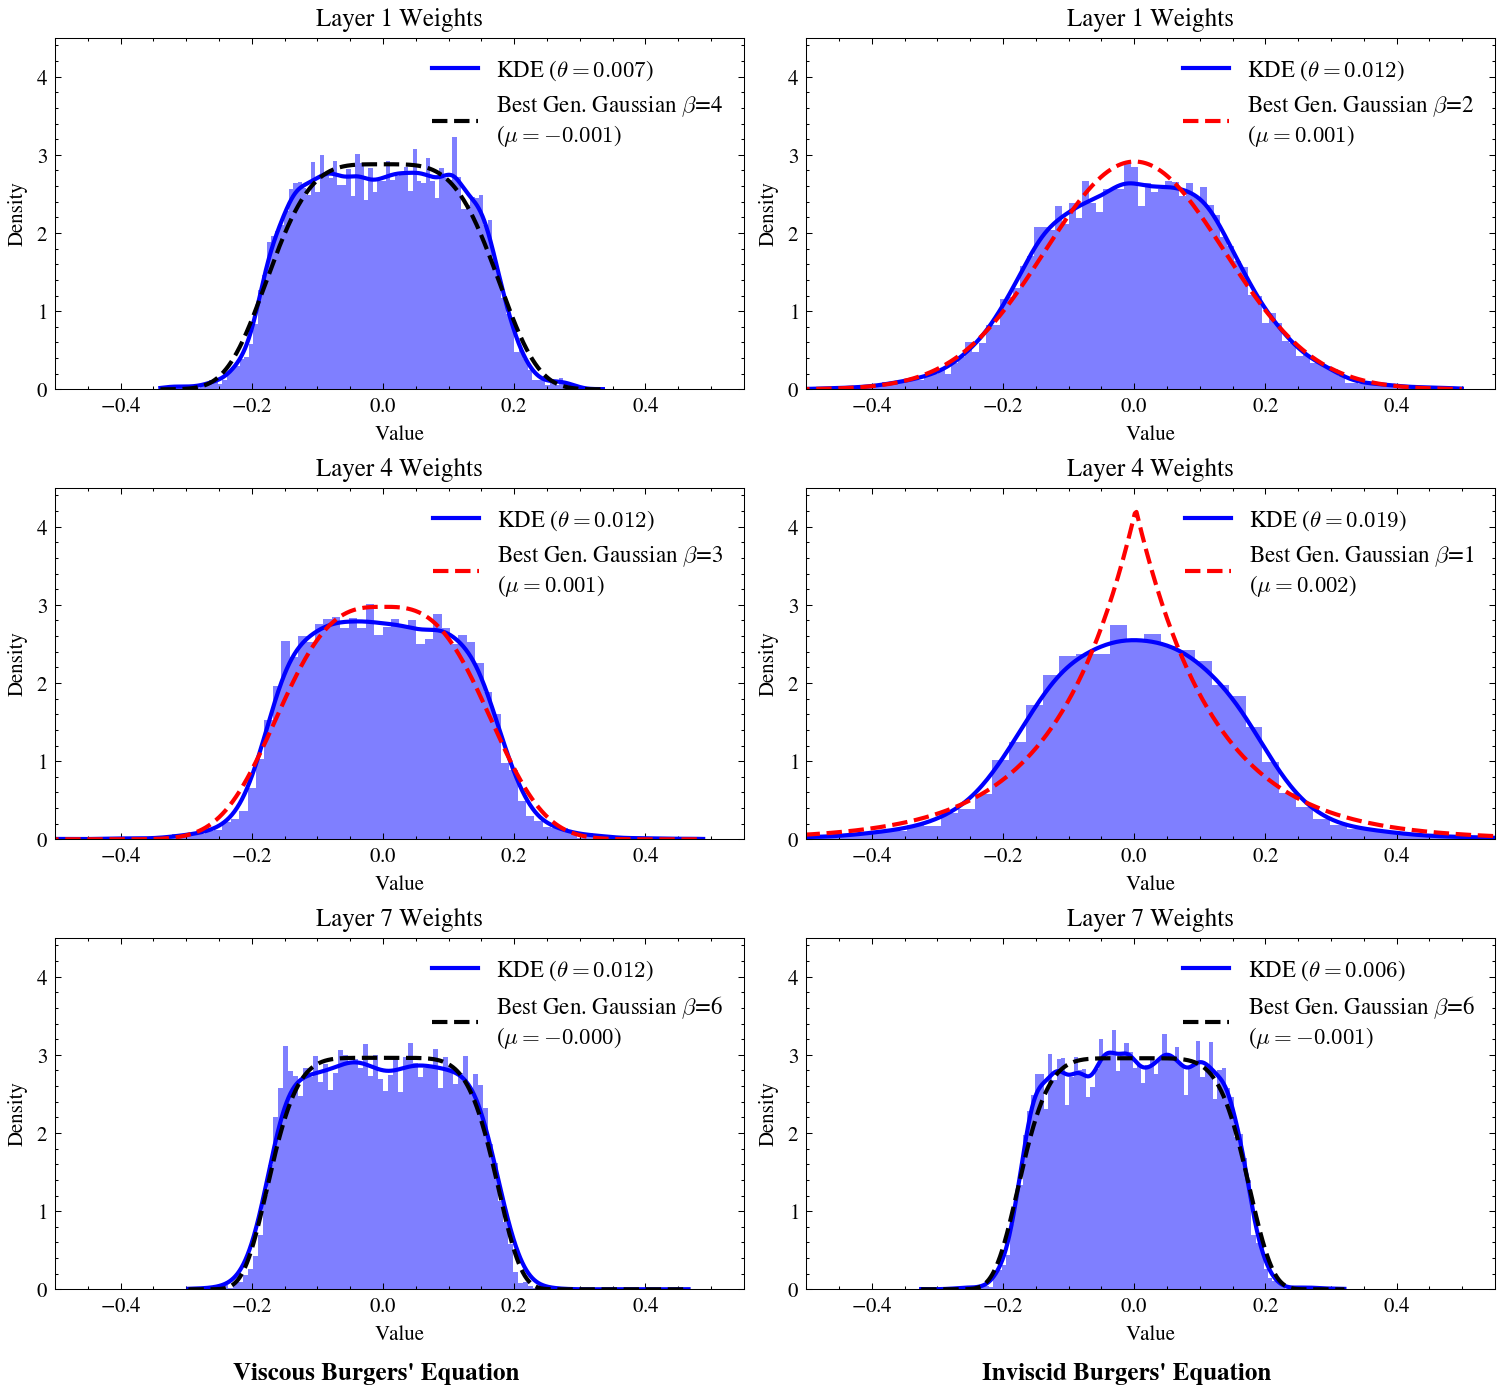

In [33]:
from scipy.optimize import minimize
from scipy.special import gamma, gammainc
from scipy.stats import kstest
from scipy.stats import norm


# ------------------------------------------------
# Generalized Gaussian PDF
# ------------------------------------------------
def generalized_gaussian_pdf(x, mu, alpha, beta):

    coeff = beta / (2.0 * alpha * gamma(1.0 / beta))

    return coeff * np.exp(- (np.abs(x - mu) / alpha) ** beta)


def fit_generalized_gaussian(data, beta=6):
    """
    Fit a generalized Gaussian distribution by moment matching.
    Returns mean, alpha (scale), and equivalent sigma.
    """
    mu = np.mean(data)
    sigma = np.std(data)
    # Relationship between sigma and alpha for generalized Gaussian
    alpha = sigma * np.sqrt(gamma(1/beta) / gamma(3/beta))
    return mu, alpha, sigma


# ------------------------------------------------
# Generalized Gaussian CDF (for KS test)
# ------------------------------------------------
def generalized_gaussian_cdf(x, mu, alpha, beta):

    z = np.abs(x - mu) / alpha
    t = z ** beta

    P = gammainc(1.0 / beta, t)

    return 0.5 + 0.5 * np.sign(x - mu) * P


# ------------------------------------------------
# Negative log-likelihood
# ------------------------------------------------
def neg_log_likelihood(params, data, beta):

    mu, log_alpha = params
    alpha = np.exp(log_alpha)

    pdf = generalized_gaussian_pdf(data, mu, alpha, beta)

    pdf = np.maximum(pdf, 1e-12)

    return -np.sum(np.log(pdf))


# ------------------------------------------------
# MLE + KS test for fixed beta
# ------------------------------------------------
def fit_beta_mle(data, beta):

    mu0 = np.mean(data)
    alpha0 = np.std(data)

    x0 = [mu0, np.log(alpha0)]

    res = minimize(
        neg_log_likelihood,
        x0,
        args=(data, beta),
        method="L-BFGS-B"
    )

    mu, log_alpha = res.x
    alpha = np.exp(log_alpha)

    # Log-likelihood
    ll = -res.fun

    # AIC (k = 2 parameters)
    aic = 4.0 - 2.0 * ll

    # KS goodness-of-fit
    cdf = lambda x: generalized_gaussian_cdf(x, mu, alpha, beta)

    ks_stat, ks_p = kstest(data, cdf)

    return mu, alpha, ll, aic, ks_stat, ks_p


# ------------------------------------------------
# Scan beta range with GoF
# ------------------------------------------------
def select_best_beta(data, beta_min=1, beta_max=8):

    results = []

    for beta in range(beta_min, beta_max + 1):

        mu, alpha, ll, aic, ks, p = fit_beta_mle(data, beta)

        results.append({
            "beta": beta,
            "mu": mu,
            "alpha": alpha,
            "loglik": ll,
            "AIC": aic,
            "KS": ks,
            "pvalue": p
        })

    df = pd.DataFrame(results)

    # Best model by AIC
    best = df.loc[df["AIC"].idxmin()]

    return (
        int(best["beta"]),
        best["mu"],
        best["alpha"],
        best["KS"],
        best["pvalue"],
        df
    )


def plot_kde_and_hist(ax, data, kde, bw, color, title,
                      hist_bins=100, limx=(-0.5, 0.55), limy=(0, 4.5), beta=6):
    x_min, x_max = data.min(), data.max()
    x_grid = np.linspace(x_min, x_max, 1000)[:, None]

    # KDE
    log_dens = kde.score_samples(x_grid)
    dens = np.exp(log_dens)

        # Automatic beta selection
    if beta is None:

        best_beta, mu, alpha, ks, pval, table = select_best_beta(data)
        if pval <= 0.045:
            c = 'red'
        else:
            c = 'black'

        fit_pdf = generalized_gaussian_pdf(
            x_grid[:, 0], mu, alpha, best_beta
        )

        fit_label = (
            rf'Best Gen. Gaussian '
            + rf'$\beta$={best_beta}'
            + "\n"
            + rf'($\mu={mu:.3f}$)'
        )

        print("\n===== Beta Scan =====")
        print(table.to_string(index=False, float_format="%.4f"))

        print(f"\nBest model:")
        print(f"beta = {best_beta}")
        print(f"KS   = {ks:.4f}")
        print(f"p    = {pval:.4e}")

        print("=====================\n")


    # Fixed beta (your old behavior)
    elif beta == 2:

        mu, sigma = np.mean(data), np.std(data)

        fit_pdf = norm.pdf(x_grid[:, 0], mu, sigma)

        fit_label = rf'Gaussian ($\mu={mu:.3f}, \sigma={sigma:.3f}$)'


    else:

        mu, alpha, sigma = fit_generalized_gaussian(data, beta=beta)

        fit_pdf = generalized_gaussian_pdf(
            x_grid[:, 0], mu, alpha, beta
        )

        fit_label = (
            rf'Gen. Gaussian $\beta$={beta}'
            + "\n"
            + rf'($\mu={mu:.3f}, \sigma={sigma:.3f}$)'
        )

    # Plot KDE
    ax.plot(x_grid[:, 0], dens, color=color, lw=2,
            label=rf'KDE ($\theta={bw*0.5:.3f}$)')

    # Plot chosen distribution
    ax.plot(x_grid[:, 0], fit_pdf, 'k--', color = c, lw=2, label=fit_label)

    # Histogram
    ax.hist(data, bins=hist_bins, density=True, alpha=0.5,
            color=color, edgecolor='none')

    ax.set_title(title)
    ax.set_xlim(limx)
    ax.set_ylim(limy)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=11, loc='upper right')




fig, axs = plt.subplots(3, 2, figsize=(10, 9), constrained_layout=True)
# Column titles
fig.text(0.25, -0.025, "Viscous Burgers' Equation",
         ha='center', va='bottom', fontsize=12, fontweight='bold')

fig.text(0.75, -0.025, "Inviscid Burgers' Equation",
         ha='center', va='bottom', fontsize=12, fontweight='bold')


# Layer 1
print("layer1 vis")
plot_kde_and_hist(axs[0, 0], W1, kde_w1, bw_w1, 'blue', "Layer 1 Weights",beta=None)

print("layer1 invis")
plot_kde_and_hist(axs[0, 1], W1_riemann, kde_w1_riemann, bw_w1_riemann, 'blue', "Layer 1 Weights",beta=None)



# Layer 4
print("layer4 vis")
plot_kde_and_hist(axs[1, 0], W4, kde_w4, bw_w4, 'blue', "Layer 4 Weights", beta= None)
print("layer4 invis")
plot_kde_and_hist(axs[1, 1], W4_riemann, kde_w4_riemann, bw_w4_riemann, 'blue', "Layer 4 Weights", beta= None)


# Layer 7
print("layer7 vis")
plot_kde_and_hist(axs[2, 0], W7, kde_w7, bw_w7, 'blue', "Layer 7 Weights", beta=None)
print("layer7 invis")
plot_kde_and_hist(axs[2, 1], W7_riemann, kde_w7_riemann, bw_w7_riemann, 'blue', "Layer 7 Weights", beta=None)





# plt.suptitle("KDE for Weights", fontsize=16)
# plt.savefig("./figs/kde_weights_combined.pdf")
plt.show()


In [34]:
# Inviscid Burgers
def print_excess_kurtosis(data, label="Data"):
    """
    Compute and print excess kurtosis for a dataset.
    Gaussian baseline = 0.
    """
    ek = kurtosis(data, fisher=False)  # fisher=True implies excess kurtosis
    print(f"Kurtosis for {label}: {ek:.4f}")
    return ek

print_excess_kurtosis(W1_riemann, "Layer 1 Weights")
print_excess_kurtosis(b1_riemann, "Layer 1 Biases")
print_excess_kurtosis(W4_riemann, "Layer 4 Weights")
print_excess_kurtosis(b4_riemann, "Layer 4 Biases")
print_excess_kurtosis(W7_riemann, "Layer 7 Weights")
print_excess_kurtosis(b7_riemann, "Layer 7 Biases")

Kurtosis for Layer 1 Weights: 2.9266
Kurtosis for Layer 1 Biases: 2.7638
Kurtosis for Layer 4 Weights: 6.4773
Kurtosis for Layer 4 Biases: 3.0054
Kurtosis for Layer 7 Weights: 1.9887
Kurtosis for Layer 7 Biases: 2.0944


2.0944152408681016


===== Continuous Beta Fit =====
mu      = -0.00128
alpha   = 0.19022
beta    = 3.86456
loglik  = 8078.64490
AIC     = -16151.28980
KS stat = 0.01575
p-value = 1.38974e-02


===== Continuous Beta Fit =====
mu      = 0.00059
alpha   = 0.20238
beta    = 2.19639
loglik  = 5706.28742
AIC     = -11406.57485
KS stat = 0.01198
p-value = 1.12428e-01


===== Continuous Beta Fit =====
mu      = 0.00107
alpha   = 0.18152
beta    = 2.58677
loglik  = 7425.12271
AIC     = -14844.24543
KS stat = 0.02388
p-value = 2.17968e-05


===== Continuous Beta Fit =====
mu      = 0.00241
alpha   = 0.17961
beta    = 1.51791
loglik  = 4687.46442
AIC     = -9368.92884
KS stat = 0.02120
p-value = 2.45083e-04


===== Continuous Beta Fit =====
mu      = -0.00081
alpha   = 0.18180
beta    = 5.95840
loglik  = 9135.86760
AIC     = -18265.73520
KS stat = 0.01361
p-value = 4.87961e-02


===== Continuous Beta Fit =====
mu      = -0.00063
alpha   = 0.17827
beta    = 4.94830
loglik  = 9151.68558
AIC     = -18297.37116
KS stat

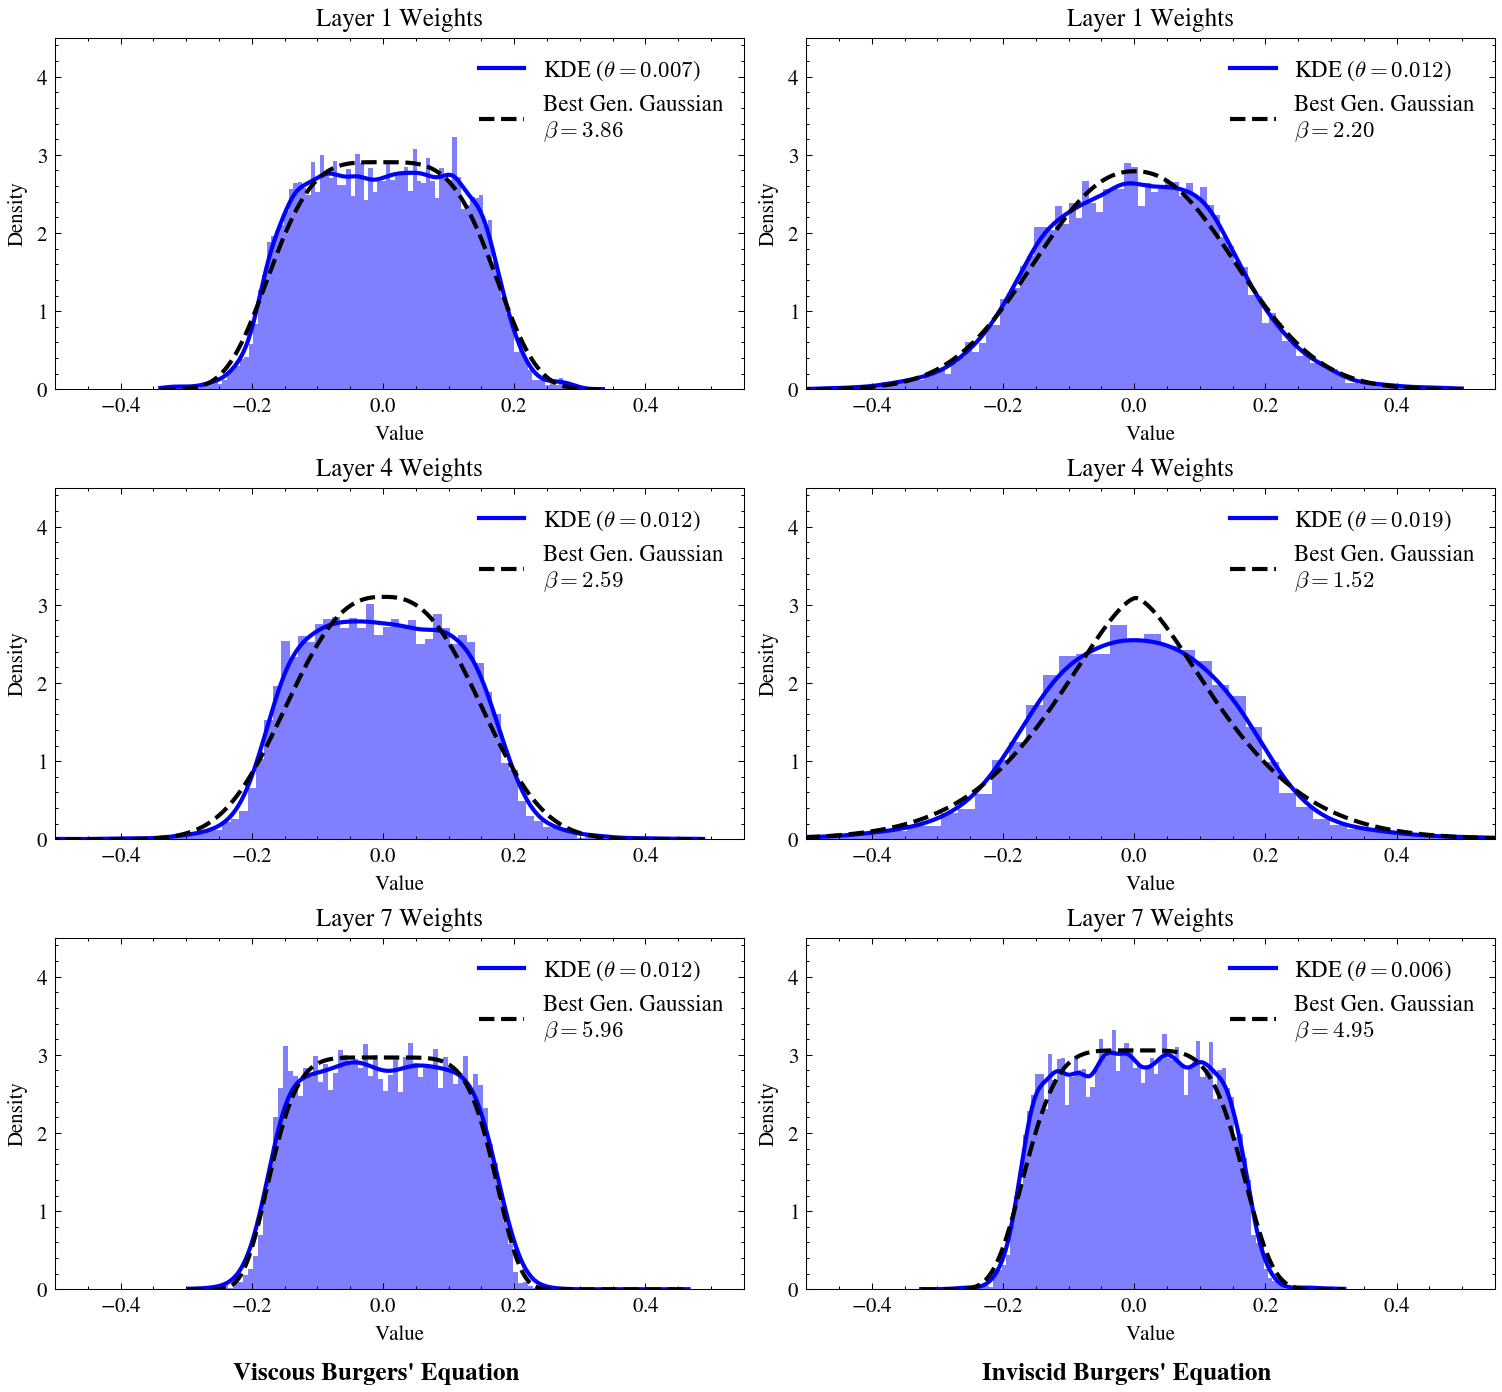


===== Summary Table =====
           Layer       mu   alpha    beta     loglik          AIC      KS  pvalue
 Layer 1 Viscous -0.00128 0.19022 3.86456 8078.64490 -16151.28980 0.01575 0.01390
Layer 1 Inviscid  0.00059 0.20238 2.19639 5706.28742 -11406.57485 0.01198 0.11243
 Layer 4 Viscous  0.00107 0.18152 2.58677 7425.12271 -14844.24543 0.02388 0.00002
Layer 4 Inviscid  0.00241 0.17961 1.51791 4687.46442  -9368.92884 0.02120 0.00025
 Layer 7 Viscous -0.00081 0.18180 5.95840 9135.86760 -18265.73520 0.01361 0.04880
Layer 7 Inviscid -0.00063 0.17827 4.94830 9151.68558 -18297.37116 0.01683 0.00687



In [35]:
from scipy.optimize import minimize
from scipy.special import gamma, gammainc
from scipy.stats import kstest


# ------------------------------------------------
# Generalized Gaussian PDF
# ------------------------------------------------
def generalized_gaussian_pdf(x, mu, alpha, beta):
    x = np.asarray(x, dtype=float)   

    coeff = beta / (2.0 * alpha * gamma(1.0 / beta))
    return coeff * np.exp(- (np.abs(x - mu) / alpha) ** beta)


# ------------------------------------------------
# Generalized Gaussian CDF (for KS test)
# ------------------------------------------------
def generalized_gaussian_cdf(x, mu, alpha, beta):
    z = np.abs(x - mu) / alpha
    t = z ** beta
    P = gammainc(1.0 / beta, t)
    return 0.5 + 0.5 * np.sign(x - mu) * P


# ------------------------------------------------
# Negative log-likelihood (beta free)
# ------------------------------------------------
def neg_log_likelihood_full(params, data):
    data = np.asarray(data, dtype=float)  
    mu, log_alpha, log_beta = params

    alpha = np.exp(log_alpha)
    beta  = np.exp(log_beta)

    pdf = generalized_gaussian_pdf(data, mu, alpha, beta)
    pdf = np.maximum(pdf, 1e-12)

    return -np.sum(np.log(pdf))


# ------------------------------------------------
# Full MLE fit with beta ∈ [1, 20]
# ------------------------------------------------
def fit_generalized_gaussian_full(data):

    mu0 = np.mean(data)
    alpha0 = np.std(data)
    beta0 = 15.0

    x0 = [mu0, np.log(alpha0), np.log(beta0)]

    bounds = [
        (None, None),              # mu
        (None, None),              # log alpha
        (np.log(1.0), np.log(20.0)) # log beta
    ]

    res = minimize(
        neg_log_likelihood_full,
        x0,
        args=(data,),
        method="L-BFGS-B",
        bounds=bounds
    )

    mu, log_alpha, log_beta = res.x
    alpha = np.exp(log_alpha)
    beta  = np.exp(log_beta)

    ll = -res.fun
    aic = 2 * 3 - 2 * ll   # k = 3 parameters

    # KS test
    cdf = lambda x: generalized_gaussian_cdf(x, mu, alpha, beta)
    ks_stat, ks_p = kstest(data, cdf)

    return {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "loglik": ll,
        "AIC": aic,
        "KS": ks_stat,
        "pvalue": ks_p
    }

# ------------------------------------------------
# Plot KDE + Best AIC Fit
# ------------------------------------------------
def plot_kde_and_hist(ax, data, kde, bw, color, title,
                      hist_bins=100, limx=(-0.5, 0.55), limy=(0, 4.5)):

    x_min, x_max = data.min(), data.max()
    x_grid = np.linspace(x_min, x_max, 1000)

    # KDE
    log_dens = kde.score_samples(x_grid[:, None])
    dens = np.exp(log_dens)

    # Fit full generalized Gaussian
    fit_res= fit_generalized_gaussian_full(data)
    mu     = fit_res["mu"]
    alpha  = fit_res["alpha"]
    beta   = fit_res["beta"]
    ll     = fit_res["loglik"]
    aic    = fit_res["AIC"]
    ks     = fit_res["KS"]
    pval   = fit_res["pvalue"]

    fit_pdf = generalized_gaussian_pdf(x_grid, mu, alpha, beta)

    print("\n===== Continuous Beta Fit =====")
    print(f"mu      = {mu:.5f}")
    print(f"alpha   = {alpha:.5f}")
    print(f"beta    = {beta:.5f}")
    print(f"loglik  = {ll:.5f}")
    print(f"AIC     = {aic:.5f}")
    print(f"KS stat = {ks:.5f}")
    print(f"p-value = {pval:.5e}")
    print("================================\n")

    # Plot KDE
    ax.plot(x_grid, dens, color=color, lw=2,
            label=rf'KDE ($\theta={bw*0.5:.3f}$)')

    # Plot best AIC model
    ax.plot(x_grid, fit_pdf, 'k--', lw=2,
            label=rf'Best Gen. Gaussian'
                  + "\n"
                  + rf'$\beta={beta:.2f}$')

    # Histogram
    ax.hist(data, bins=hist_bins, density=True, alpha=0.5,
            color=color, edgecolor='none')

    ax.set_title(title)
    ax.set_xlim(limx)
    ax.set_ylim(limy)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=11, loc='upper right')

    return {
        "mu": mu,
        "alpha": alpha,
        "beta": beta,
        "loglik": ll,
        "AIC": aic,
        "KS": ks,
        "pvalue": pval
    }
# ------------------------------------------------
# Figure
# ------------------------------------------------


results = []
fig, axs = plt.subplots(3, 2, figsize=(10, 9), constrained_layout=True)

fig.text(0.25, -0.025, "Viscous Burgers' Equation",
         ha='center', va='bottom', fontsize=12, fontweight='bold')

fig.text(0.75, -0.025, "Inviscid Burgers' Equation",
         ha='center', va='bottom', fontsize=12, fontweight='bold')


# Layer 1
res = plot_kde_and_hist(axs[0, 0], W1, kde_w1, bw_w1, 'blue', "Layer 1 Weights")
results.append({"Layer": "Layer 1 Viscous", **res})
res = plot_kde_and_hist(axs[0, 1], W1_riemann, kde_w1_riemann, bw_w1_riemann, 'blue', "Layer 1 Weights")
results.append({"Layer": "Layer 1 Inviscid", **res})


# Layer 4
res = plot_kde_and_hist(axs[1, 0], W4, kde_w4, bw_w4, 'blue', "Layer 4 Weights")
results.append({"Layer": "Layer 4 Viscous", **res})

res = plot_kde_and_hist(axs[1, 1], W4_riemann, kde_w4_riemann, bw_w4_riemann, 'blue', "Layer 4 Weights")
results.append({"Layer": "Layer 4 Inviscid", **res})

# Layer 7
res = plot_kde_and_hist(axs[2, 0], W7, kde_w7, bw_w7, 'blue', "Layer 7 Weights")
results.append({"Layer": "Layer 7 Viscous", **res})

res = plot_kde_and_hist(axs[2, 1], W7_riemann, kde_w7_riemann, bw_w7_riemann, 'blue', "Layer 7 Weights")
results.append({"Layer": "Layer 7 Inviscid", **res})


# plt.savefig("./figs/kde_weights_combined_continuous.pdf")
plt.show()
df_results = pd.DataFrame(results)
print("\n===== Summary Table =====")
print(df_results.to_string(index=False, float_format="%.5f"))
print("=========================\n")

Integral: 1.1141853757113152


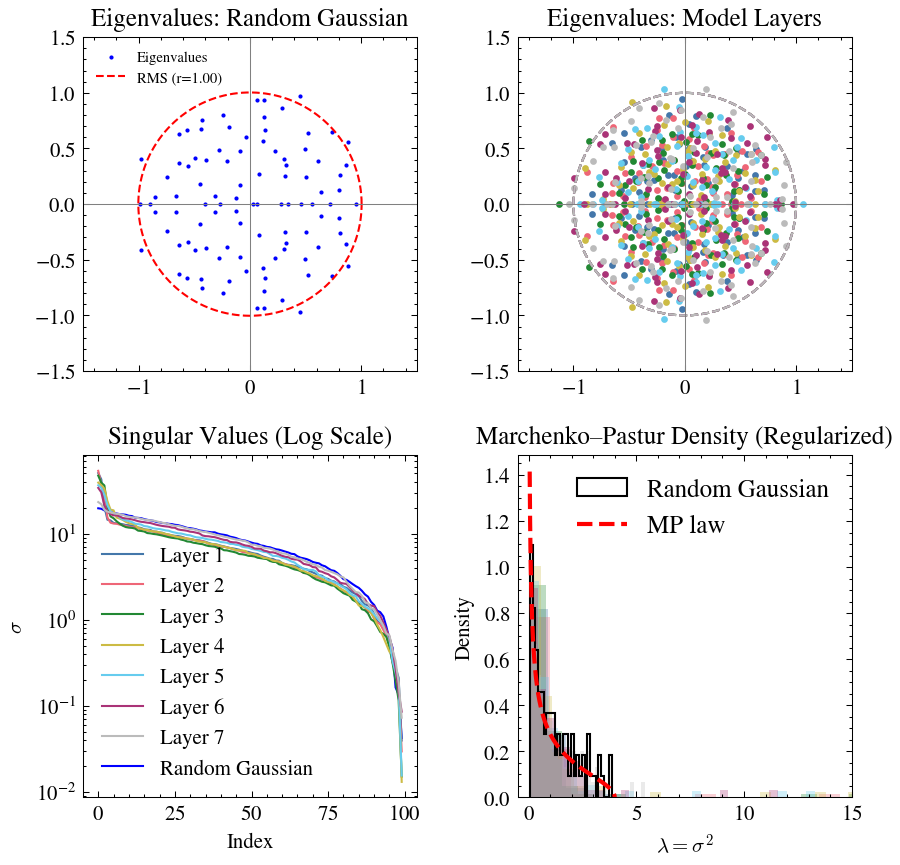

In [36]:
import matplotlib.gridspec as gridspec

def get_eigen_spectrum(W, label):
    n = W.shape[0]
    assert n == W.shape[1], f"{label} is not square!"
    rms = np.sqrt(np.mean(W**2))
    W_scaled = W / np.sqrt(n)
    eigvals = np.linalg.eigvals(W_scaled)
    return eigvals, rms

def get_singular_spectrum(W):
    return np.linalg.svd(W, compute_uv=False)

def mp_density(lam, q):
    lam_plus = (1 + np.sqrt(q))**2
    lam_minus = (1 - np.sqrt(q))**2
    rho = np.zeros_like(lam)
    mask = (lam >= lam_minus) & (lam <= lam_plus)
    rho[mask] = np.sqrt((lam_plus - lam[mask]) *
                        (lam[mask] - lam_minus)) / (2 * np.pi * q * lam[mask])
    return rho


lam_test = np.linspace(1e-6, 4.0, 5000)
rho = mp_density(lam_test, q=1.0)
print("Integral:", np.trapz(rho, lam_test))


# ============================
# Figure layout (2x2)
# ============================
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
ax0, ax1, ax2, ax3 = axes.flatten()

theta = np.linspace(0, 2*np.pi, 300)
layer_indices = [1,2,3,4,5,6,7]

# --- Top-left: Random Gaussian matrix eigenvalues
np.random.seed(42)
eigvals, rms = get_eigen_spectrum(W_random, "Random Gaussian")

ax0.scatter(eigvals.real, eigvals.imag, s=1, color='blue', label='Eigenvalues')
ax0.plot(rms * np.cos(theta), rms * np.sin(theta), 'r--', label=f'RMS (r={rms:.2f})')
ax0.set_title("Eigenvalues: Random Gaussian")
ax0.set_aspect('equal')
ax0.axhline(0, color='gray', lw=0.5)
ax0.axvline(0, color='gray', lw=0.5)
ax0.set_xlim([-1.5,1.5])
ax0.set_ylim([-1.5,1.5])
ax0.legend(loc='upper left', fontsize=7)

# --- Top-right: Eigenvalues of model layers
layer_indices = [1,2,3,4,5,6,7]
for idx in layer_indices:
    W = model_riemann.net.layers[idx].get_weights()[0]
    _, rms = get_eigen_spectrum(W, f"Layer {idx}")
    W *= 1 / rms
    eigvals, rms = get_eigen_spectrum(W, f"Layer {idx}")
    ax1.scatter(eigvals.real, eigvals.imag, s=5)
    ax1.plot(rms * np.cos(theta), rms * np.sin(theta), '--', lw=1, label=f'L{idx} (r={rms:.2e})')
ax1.set_title("Eigenvalues: Model Layers")
ax1.set_aspect('equal')
ax1.axhline(0, color='gray', lw=0.5)
ax1.axvline(0, color='gray', lw=0.5)
ax1.set_xlim([-1.5, +1.5])
ax1.set_ylim([-1.5, +1.5])
# ax1.legend(loc='upper left', fontsize=6)

# ============================
# (1,0) Singular values (log)
# ============================
for idx in layer_indices:
    W = model_riemann.net.layers[idx].get_weights()[0]
    _, rms = get_eigen_spectrum(W, f"Layer {idx}")
    W *= 1 / rms
    s = get_singular_spectrum(W)
    ax2.semilogy(s, label=f"Layer {idx}")
s_random = get_singular_spectrum(W_random)
ax2.semilogy(s_random, color='blue', label='Random Gaussian',zorder=1)
ax2.set_title("Singular Values (Log Scale)")
ax2.set_xlabel("Index")
ax2.set_ylabel(r"$\sigma$")
ax2.legend(fontsize=10)
# ============================
# (1,1) MP density validation (regularized)
# ============================
bins = 30
q = 1.0

# MP support
lam_minus = (1 - np.sqrt(q))**2
lam_plus  = (1 + np.sqrt(q))**2

# Finite-size regularization cutoff
lam_cut = 0.05   # scientifically acceptable for N~100

# --- Trained layers
# target = 7
for idx in (layer_indices):
    
    # if idx != target:
    #  continue

    W = model_riemann.net.layers[idx].get_weights()[0]
    n = W.shape[0]
    W = W / np.sqrt(np.mean(W**2))  # unit variance
    s = np.linalg.svd(W, compute_uv=False)
    lam = (s**2) / n
    lam = lam[lam > lam_cut]
    ax3.hist(lam, bins=bins, density=True, alpha=0.3)

# --- Random Gaussian
s_rand = np.linalg.svd(W_random, compute_uv=False)
lam_rand = (s_rand**2) / W_random.shape[0]
lam_rand = lam_rand[lam_rand > lam_cut]
ax3.hist(lam_rand, bins=bins, density=True,
         histtype='step', color='k',
         label='Random Gaussian')

# --- MP curve (regularized)
lam_plot = np.linspace(lam_cut, lam_plus, 400)
ax3.plot(lam_plot, mp_density(lam_plot, q),
         'r--', lw=2, label='MP law')

ax3.set_title("Marchenko–Pastur Density (Regularized)")
ax3.set_xlabel(r"$\lambda = \sigma^2$")
ax3.set_ylabel("Density")
ax3.set_xlim([-0.5,15])
ax3.legend(fontsize=12)
# plt.suptitle("Inviscid Burgers' Equation")
plt.tight_layout()
# plt.savefig("./figs/eigen_spectrum_and_singular_values_riemann.pdf")



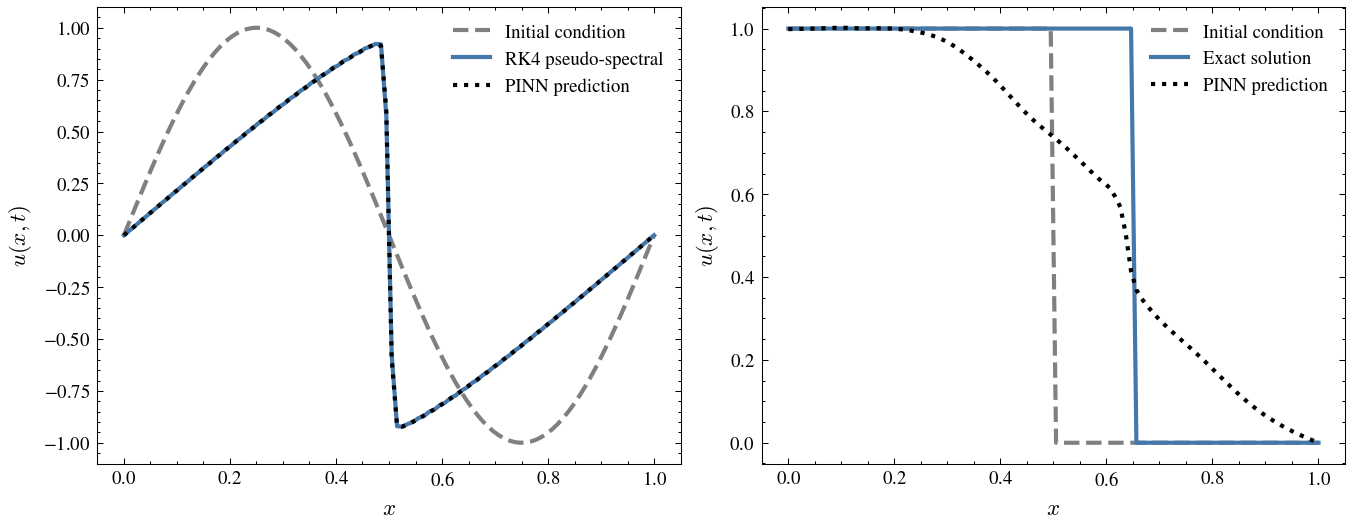

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)

for ax in axs:
    ax.grid(False)
    ax.tick_params(
        labelsize=9,
        direction="in",
        top=True,
        right=True
    )
t=0.3
x_test = x
t_test = np.full_like(x_test,t * time)
x_test = x_test.reshape(-1, 1)
t_test = t_test.reshape(-1, 1)
# --------------------
# Left panel
# --------------------
axs[0].plot(
    x_test,
    u_initial_sine(x_test),
    '--',
    color='gray',
    linewidth=2,
    label='Initial condition'
)

axs[0].plot(
    x_test,
    u_FD_sine,
    linewidth=2,
    label='RK4 pseudo-spectral'
)

u_pred_sine = model(tf.concat([x_test, t_test], axis=1)).numpy()
axs[0].plot(
    x_test,
    u_pred_sine,
    ':',
    color='black',
    linewidth=2,
    label='PINN prediction'
)

axs[0].set_xlabel(r"$x$", fontsize=11)
axs[0].set_ylabel(r"$u(x,t)$", fontsize=11)
# axs[0].set_title("Smooth initial condition", fontsize=11)
axs[0].legend(fontsize=9, frameon=False)

# --------------------
# Right panel
# --------------------
axs[1].plot(
    x_test,
    riemann_function(x_test),
    '--',
    color='gray',
    linewidth=2,
    label='Initial condition'
)

u_exact = exact_riemann_solution(x, t)
axs[1].plot(
    x_test,
    u_exact,
    linewidth=2,
    label='Exact solution'
)

u_pred_riemann = model_riemann(tf.concat([x_test, t_test], axis=1)).numpy()
axs[1].plot(
    x_test,
    u_pred_riemann,
    ':',
    color='black',
    linewidth=2,
    label='PINN prediction'
)

axs[1].set_xlabel(r"$x$", fontsize=11)
axs[1].set_ylabel(r"$u(x,t)$", fontsize=11)
axs[1].legend(fontsize=9, frameon=False)
plt.show()
